DATASET ABOUT THE RISKS OF HEART ATTACKS


In [28]:
import pandas as pd
import numpy as np
from google.colab import drive


df=pd.read_csv('/content/heart_attack_prediction_dataset.csv')
display(df.head())

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [29]:
df.shape    # no of rows and  columns
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [30]:
df.shape  ## Dimension of data

(8763, 26)

In [31]:
from scipy.stats import ttest_ind
# The columns 'Smoking' and 'Cholesterol_Level' are not present in the DataFrame 'df'.
# Please check the available columns: df.columns
# If you intended to use 'Chol' for cholesterol, consider replacing 'Cholesterol_Level' with 'Chol'.
# If you need 'Smoking' data, you might need to load a different dataset or perform feature engineering.
# smokers = df[df['Smoking'] == 1]

# Extract cholesterol data for smokers and non-smokers
# male_smokers = smokers[smokers['Sex'] == 'Male']['Cholesterol_Level']
# female_smokers = smokers[smokers['Sex'] == 'Female']['Cholesterol_Level']

In [32]:
print("The mean blood cholesterol level of males who smoke is equal to the mean blood cholesterol level of females who smoke.")
print("Alternative Hypothesis (H1): The mean blood cholesterol level of males who smoke is not equal to the mean blood cholesterol level of females who smoke.")
alpha= 0.05
print("alpha:", alpha)

The mean blood cholesterol level of males who smoke is equal to the mean blood cholesterol level of females who smoke.
Alternative Hypothesis (H1): The mean blood cholesterol level of males who smoke is not equal to the mean blood cholesterol level of females who smoke.
alpha: 0.05


In [36]:
# The variables 'male_smokers' and 'female_smokers' are not defined.
# This is because the columns 'Smoking' and 'Cholesterol_Level' are not present in the dataframe 'df'.
# If you intend to compare cholesterol levels between males and females using the 'Cholesterol' and 'Sex' columns:

male_chol = df[df['Sex'] == 'Male']['Cholesterol']
female_chol = df[df['Sex'] == 'Female']['Cholesterol']

t_statistic, p_value = ttest_ind(male_chol, female_chol, equal_var=True)
print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 0.7126642818933326
p-value: 0.4760725032969768


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

,0
Female,"Axes(0.1,0.15;0.363636x0.75)"
Male,"Axes(0.536364,0.15;0.363636x0.75)"


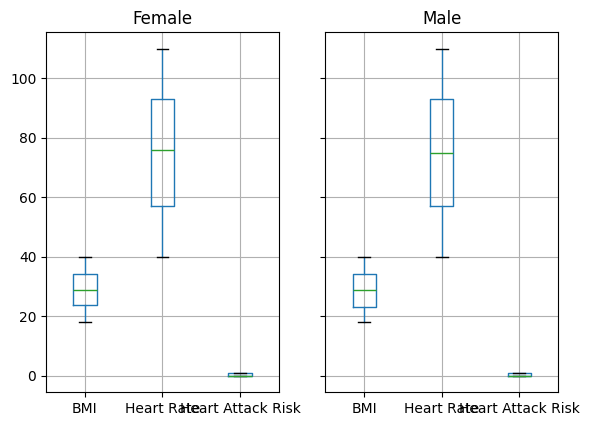

In [38]:
groupby_gender = df.groupby('Sex')
groupby_gender.boxplot(column=['BMI','Heart Rate', 'Heart Attack Risk'])


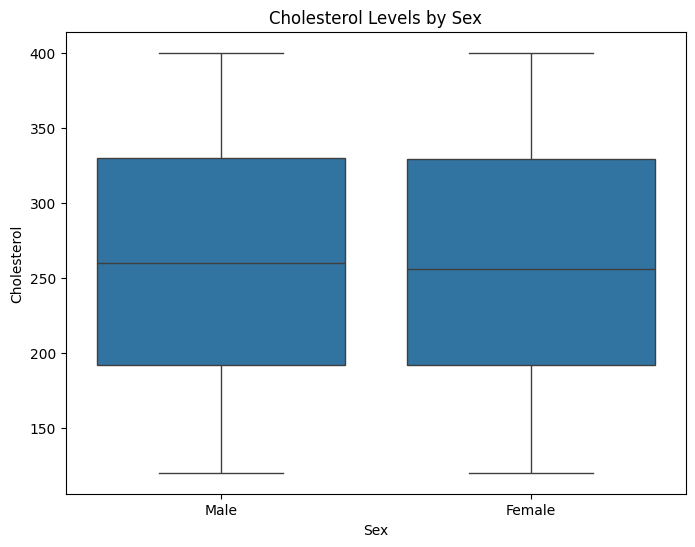

In [60]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sex', y='Cholesterol', data=df)
plt.title('Cholesterol Levels by Sex')
plt.xlabel('Sex')
plt.ylabel('Cholesterol')
plt.show()

In [39]:
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in blood cholesterol levels between male and female smokers.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in blood cholesterol levels between male and female smokers.")

Fail to reject the null hypothesis: There is no significant difference in blood cholesterol levels between male and female smokers.


In [40]:
print("Null Hypothesis: The mean heart rate of patients (both male and female) before weight loss is the same as the mean blood pressure after weight loss.")
print("Alternative Hypothesis: The mean heart rate of patients (both male and female) before weight loss is not the same as the mean blood pressure after weight loss")

Null Hypothesis: The mean heart rate of patients (both male and female) before weight loss is the same as the mean blood pressure after weight loss.
Alternative Hypothesis: The mean heart rate of patients (both male and female) before weight loss is not the same as the mean blood pressure after weight loss


In [41]:
# The columns 'Heart_Rate_Before_Weight_Loss' and 'Heart_Rate_After_Weight_Loss' are not present in the DataFrame 'df'.
# Please check the available columns in 'df' (e.g., df.columns) and update the column names accordingly,
# or ensure you have loaded the correct dataset that contains these columns.
# hr_before = df['Heart_Rate_Before_Weight_Loss']
# mean_hr_before = hr_before.mean()
# hr_after = df['Heart_Rate_After_Weight_Loss']
# mean_hr_after = hr_after.mean()

In [42]:
# from stats import ttest_rel
# t_statistic, p = stats.ttest_rel(hr_before, hr_after)
# print("Paired Sample t-test results:")
# print(f"T-statistic: {t_statistic}")
# print(f"P-value: {p_value}")
# if p_value < 0.05:
#     print("\nReject the null hypothesis.")
# else:
#     print("\nFail to reject the null hypothesis.")

# print("A high p-value (close to 1) suggests that there is not enough evidence to reject the null hypothesis.")

In [44]:
from statsmodels.formula.api import ols
df=pd.read_csv('/content/heart_attack_prediction_dataset.csv')
model = ols("Cholesterol ~ Age", df).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Cholesterol   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7267
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.394
Time:                        17:05:26   Log-Likelihood:                -50927.
No. Observations:                8763   AIC:                         1.019e+05
Df Residuals:                    8761   BIC:                         1.019e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    261.7385      2.348    111.467      0.0

In [48]:
df = df.rename(columns={'Heart Rate': 'Heart_Rate'})
model2 = ols('Cholesterol ~ Heart_Rate', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            Cholesterol   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 0.0008688
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.976
Time:                        17:06:36   Log-Likelihood:                -50927.
No. Observations:                8763   AIC:                         1.019e+05
Df Residuals:                    8761   BIC:                         1.019e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    259.7843      3.270     79.446      0.0

In [50]:
# one way anova
from scipy.stats import f_oneway
result = f_oneway(
    df[df['Age'] < 35 ]['Cholesterol'],
    df[(df['Age'] >= 35) & (df['Age'] <= 65)]['Cholesterol'],
    df[df['Age']  > 55]['Cholesterol'],
)

print("One-way ANOVA results:")
print("F-statistic:", result.statistic)
print("p-value:", result.pvalue)

One-way ANOVA results:
F-statistic: 0.025598131181823688
p-value: 0.9747267873072711


In [51]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
# performing type 2 anova test
aovtable = sm.stats.anova_lm(model2)

In [52]:
print('ANOVA table for Heart Rate')
print('----------------------')
print(aovtable)
print()

ANOVA table for Heart Rate
----------------------
                df        sum_sq      mean_sq         F    PR(>F)
Heart_Rate     1.0  5.681647e+00     5.681647  0.000869  0.976486
Residual    8761.0  5.729357e+07  6539.615135       NaN       NaN



In [54]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
multiComp = MultiComparison(df['Cholesterol'], df['Sex'])
tukeyres = multiComp.tukeyhsd(alpha = 0.05)
print(tukeyres)
print('Unique groups: ', multiComp.groupsunique)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Female   Male   1.3401 0.4761 -2.3459 5.0261  False
---------------------------------------------------
Unique groups:  ['Female' 'Male']


In [57]:
model = ols(
    'Cholesterol~ Sex+Age', data=df).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
Sex,3.483972e+03,1.0,0.532765,0.465466
Age,4.914551e+03,1.0,0.751527,0.386017
Residual,5.728534e+07,8760.0,NaN,NaN


In [63]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
multiComp = MultiComparison(df['Cholesterol'], df['Sex'])
tukeyres = multiComp.tukeyhsd(alpha = 0.05)
print(tukeyres)
print('Unique groups: ', multiComp.groupsunique)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Female   Male   1.3401 0.4761 -2.3459 5.0261  False
---------------------------------------------------
Unique groups:  ['Female' 'Male']


(array([470., 406., 435., 423., 380., 472., 442., 415., 480., 483., 443.,
        425., 448., 422., 424., 420., 401., 471., 466., 437.]),
 array([120., 134., 148., 162., 176., 190., 204., 218., 232., 246., 260.,
        274., 288., 302., 316., 330., 344., 358., 372., 386., 400.]),
 <BarContainer object of 20 artists>)

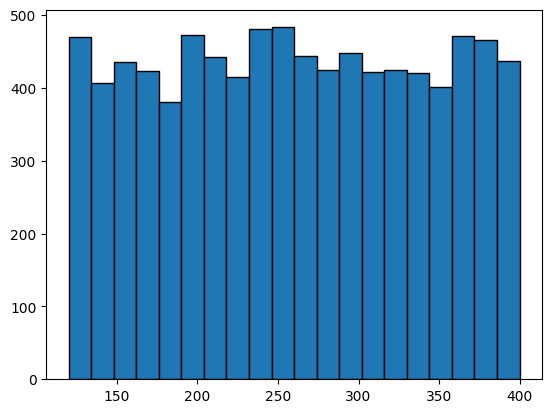

In [65]:
##Test of normality
#create histogram to visualize values in dataset
plt.hist(df['Cholesterol'], edgecolor='black', bins=20)

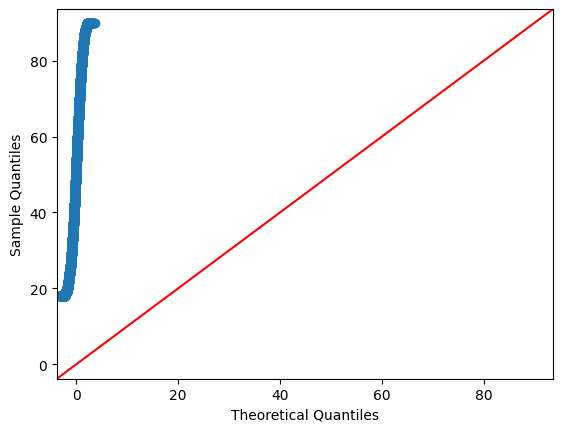

In [66]:
##Test of Normality
#create Q-Q plot with 45-degree line added to plot
fig = sm.qqplot(df['Age'], line='45')

plt.show()

In [67]:
##Test of normality
#perform Shapiro-Wilk test for normality (h0 is data is normal)
from scipy.stats import shapiro
shapiro(df['Age'])

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8763.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9527395147647509), pvalue=np.float64(1.8992837622595293e-46))

In [68]:
import scipy.stats as stats
import numpy as np
# numbe of patients from each province
observed_freq = [25,16, 10, 7, 8, 4, 10]
expected_freq = [22, 14, 11, 8, 13, 3, 9]

In [69]:
print(stats.chi2.ppf(1-0.05, df=6))

12.591587243743977


In [70]:
chi_square_test_statistic, p_value = stats.chisquare(
    observed_freq, expected_freq)
# chi square test statistic and p value
print('chi_square_test_statistic is : ' +
      str(chi_square_test_statistic))
print('p_value : ' + str(p_value))


chi_square_test_statistic is : 3.2782356532356536
p_value : 0.7732017778136523


In [71]:
contingency_table = pd.crosstab(df['Sex'], df['Age'])

print("Contingency Table:")
print(contingency_table)


Contingency Table:
Age     18  19  20  21  22  23  24  25  26  27  ...  81  82  83  84  85  86  \
Sex                                             ...                           
Female  33  45  46  37  29  41  42  49  33  39  ...  36  39  32  42  30  25   
Male    90  83  84  80  95  67  88  83  79  86  ...  77  88  83  84  88  80   

Age     87  88  89   90  
Sex                      
Female  37  34  30   41  
Male    89  89  87  111  

[2 rows x 73 columns]


In [72]:
## CHi-Sqaure Test of Association
##H0  Two variables are independent
##H1: Two variables are associated
from scipy.stats import chi2_contingency
stat, p, dof, expected = chi2_contingency(contingency_table)
# interpret p-value
alpha = 0.05
print("Chi value is " + str(stat))
print("Chi value is " + str(dof))
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

Chi value is 63.58943005455847
Chi value is 72
p value is 0.7498586849998017
Independent (H0 holds true)
